# Notebook 2: Cross-simulation variance of the diagnostic

For each of the first $P$ simulations under `output/barotropic_stirring-T85/simulations/`, detect spinup_time from the global enstrophy series, compute the diagnostic $D_n$ = time-mean zonal-mean of $u$ over $[t_s, M_n]$, and plot all $P$ diagnostics together with their ensemble mean and one-standard-deviation envelope.

All computations come from `ml.diagnostics`: `compute_enstrophy`, `find_spinup_time`, `compute_time_mean_zonal_mean`.

In [1]:
P = 10
SIMS_DIR = "../../output/barotropic_stirring-T85/simulations"

In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

plt.rcParams["figure.dpi"] = 120

from ml.cmd.rotating_globe import load_data
from ml.diagnostics import (
    compute_enstrophy,
    compute_time_mean_zonal_mean,
    find_spinup_time,
)

In [3]:
sims_root = Path(SIMS_DIR)
diagnostics = []
spinup_times = []
lat = None

for n in tqdm(range(P), desc="simulations"):
    ds = load_data(str(sims_root / str(n)))
    vor = ds.vor.values
    u = ds.ucomp.values
    if lat is None:
        lat = ds.lat.values
    M = vor.shape[0]
    spinup_time = find_spinup_time(compute_enstrophy(vor, lat))
    spinup_times.append(spinup_time)
    diagnostics.append(compute_time_mean_zonal_mean(u, spinup_time, M))

diagnostics = np.stack(diagnostics, axis=0)
print(f"spinup_time per simulation: {spinup_times}")

simulations:   0%|          | 0/10 [00:00<?, ?it/s]

spinup_time per simulation: [9, 37, 12, 19, 13, 15, 47, 18, 22, 14]


In [4]:
ensemble_mean = diagnostics.mean(axis=0)
ensemble_std = diagnostics.std(axis=0, ddof=1)
print(f"Max envelope width: {2 * ensemble_std.max():.3f} m/s")

Max envelope width: 3.525 m/s


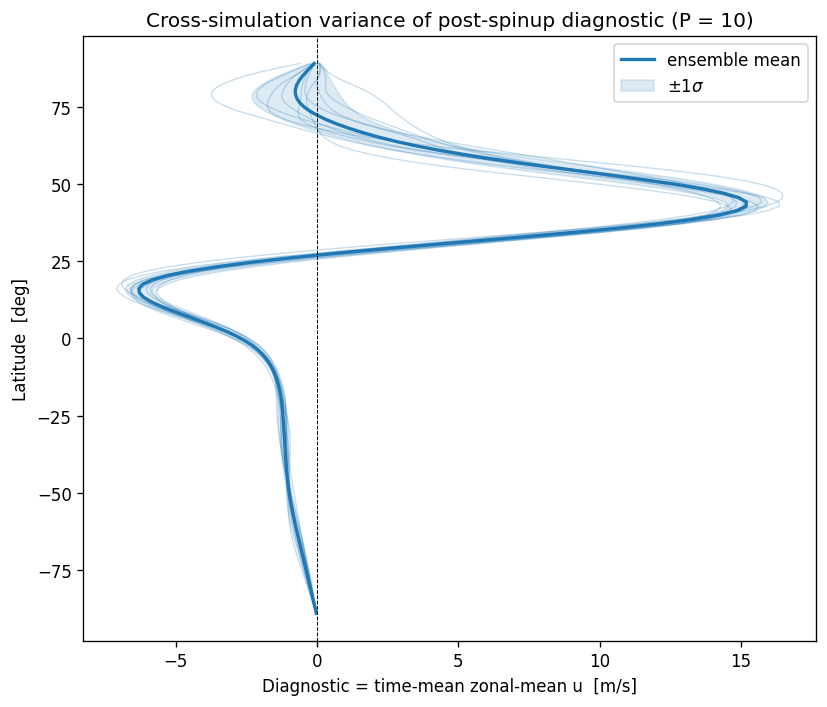

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
for n in range(P):
    ax.plot(diagnostics[n], lat, color="C0", alpha=0.25, linewidth=0.8)
ax.plot(ensemble_mean, lat, color="C0", linewidth=2.0, label="ensemble mean")
ax.fill_betweenx(
    lat,
    ensemble_mean - ensemble_std,
    ensemble_mean + ensemble_std,
    color="C0",
    alpha=0.15,
    label=r"$\pm 1\sigma$",
)
ax.axvline(0.0, color="k", linestyle="--", linewidth=0.6)
ax.set_xlabel("Diagnostic = time-mean zonal-mean u  [m/s]")
ax.set_ylabel("Latitude  [deg]")
ax.set_title(f"Cross-simulation variance of post-spinup diagnostic (P = {P})")
ax.legend()
plt.tight_layout()
plt.show()